In [127]:
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import corner
import matplotlib.lines as mlines

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 16

from pypalettes import load_cmap


Peach = load_cmap('Peach', cmap_type = 'continuous')

Concha = load_cmap('Concha', cmap_type = 'continuous')

Magenta = load_cmap('Magenta', cmap_type = 'continuous')

Burg = load_cmap('Burg', cmap_type = 'continuous')

DM = load_cmap('DarkMint', cmap_type = 'continuous')


In [131]:
len(DM.colors)

7

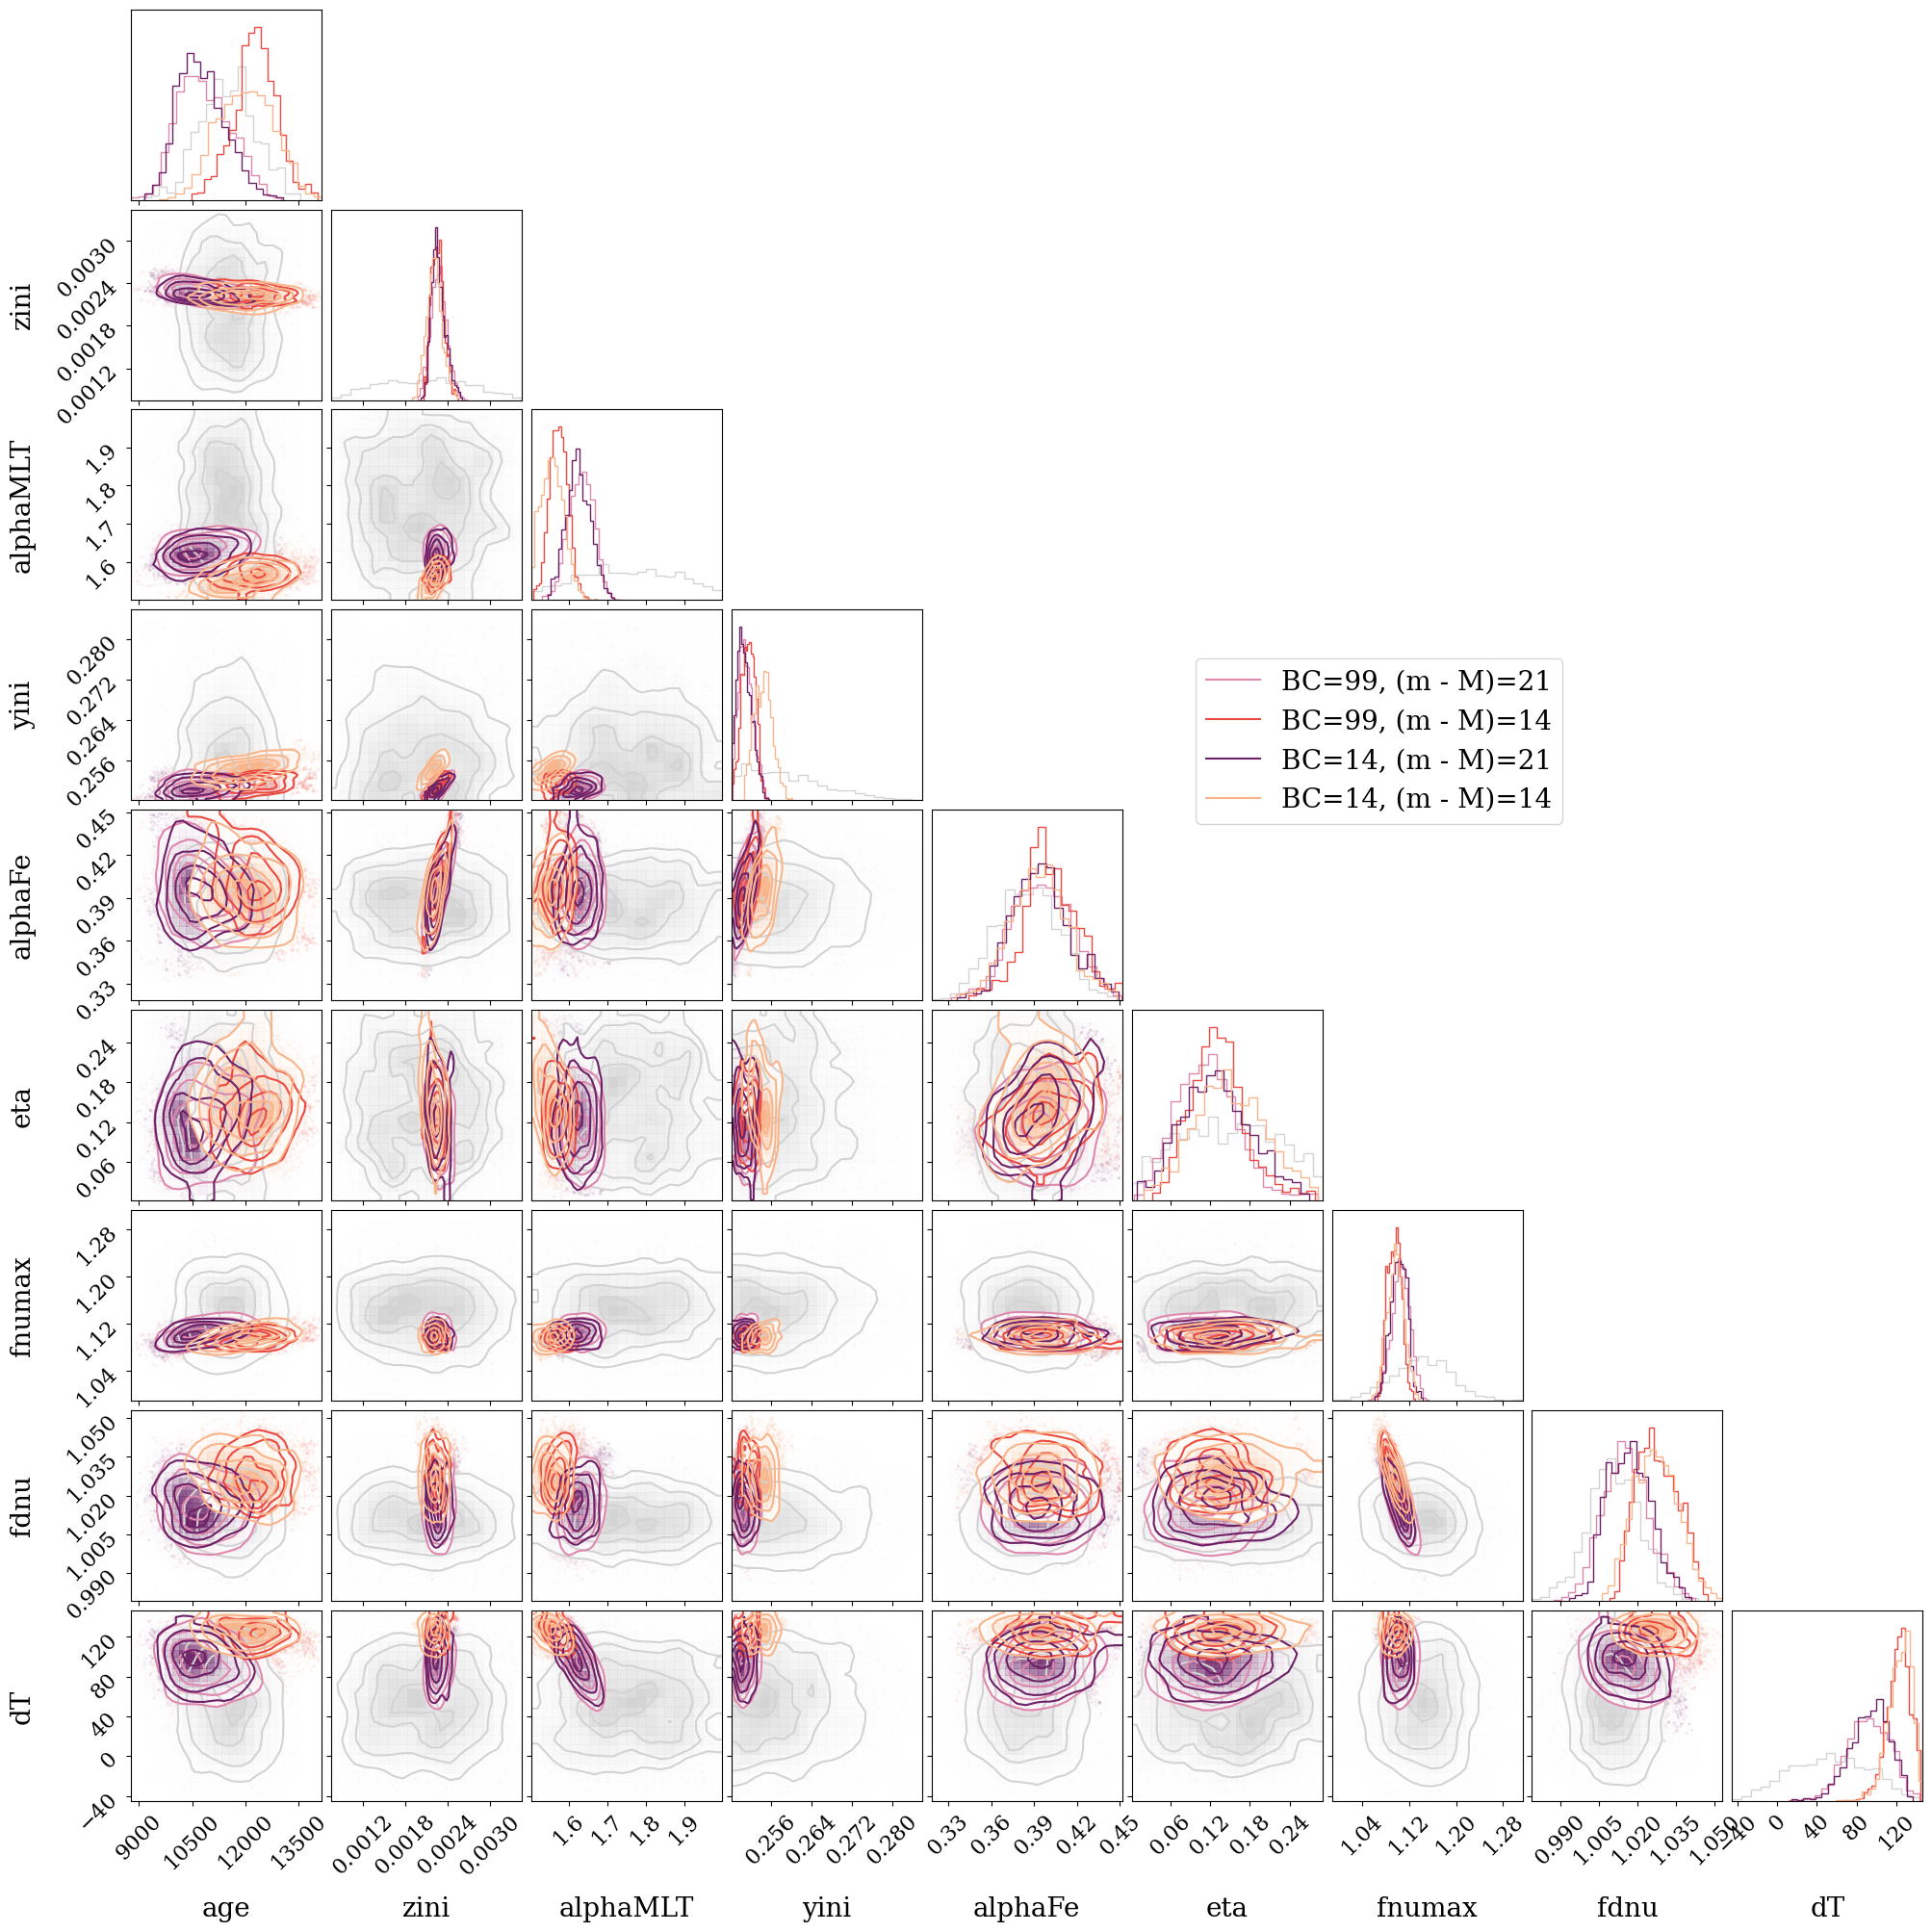

In [151]:
cases = ['A', 'B', 'C', 'D']

labels = ['BC=99, (m - M)=21', 'BC=99, (m - M)=14', 'BC=14, (m - M)=21', 'BC=14, (m - M)=14']

dd = {'A':None, 'B':None, 'C':None, 'D':None}

fig = plt.figure(figsize = (20,20))

colors = ['darkseagreen', 'violet', 'seagreen', 'darkmagenta']

colors = [Magenta.colors[2], Peach.colors[6], Magenta.colors[6], Peach.colors[2]]

params =  ['age', 'zini', 'alphaMLT', 'yini', 'alphaFe', 'eta', 'fnumax', 'fdnu', 'dT']

lines = []
for i in range(len(cases)):

    dd[cases[i]] = az.from_json(f'../M4/results-pbjam-maddy-dT-fdnu-fnumax-case-{cases[i]}.json')

    if i == 0:
        corner.corner(dd[cases[i]], group="prior", var_names = params,  smooth = True, fig = fig, hist_kwargs={'density':True}, color = 'lightgray', labels = params,  label_kwargs={ 'fontsize':20}, tick_kwargs={'fontsize':16}, labelpad = 0.2)

    lines.append(mlines.Line2D([], [], color=colors[i], label=labels[i]))

    corner.corner(dd[cases[i]], group="posterior", var_names = params,  smooth = True, fig = fig, hist_kwargs={'density':True}, color = colors[i], labels = params,  label_kwargs={ 'fontsize':20}, tick_kwargs={'fontsize':16}, labelpad = 0.2)


fig.legend(handles=lines, bbox_to_anchor = (0., 0.65, 0.8, 0.),loc = 'upper right',  fontsize = 20)

fig.savefig('../M4/figs/compare-lum-posteriors.png', bbox_inches = 'tight', dpi = 300)

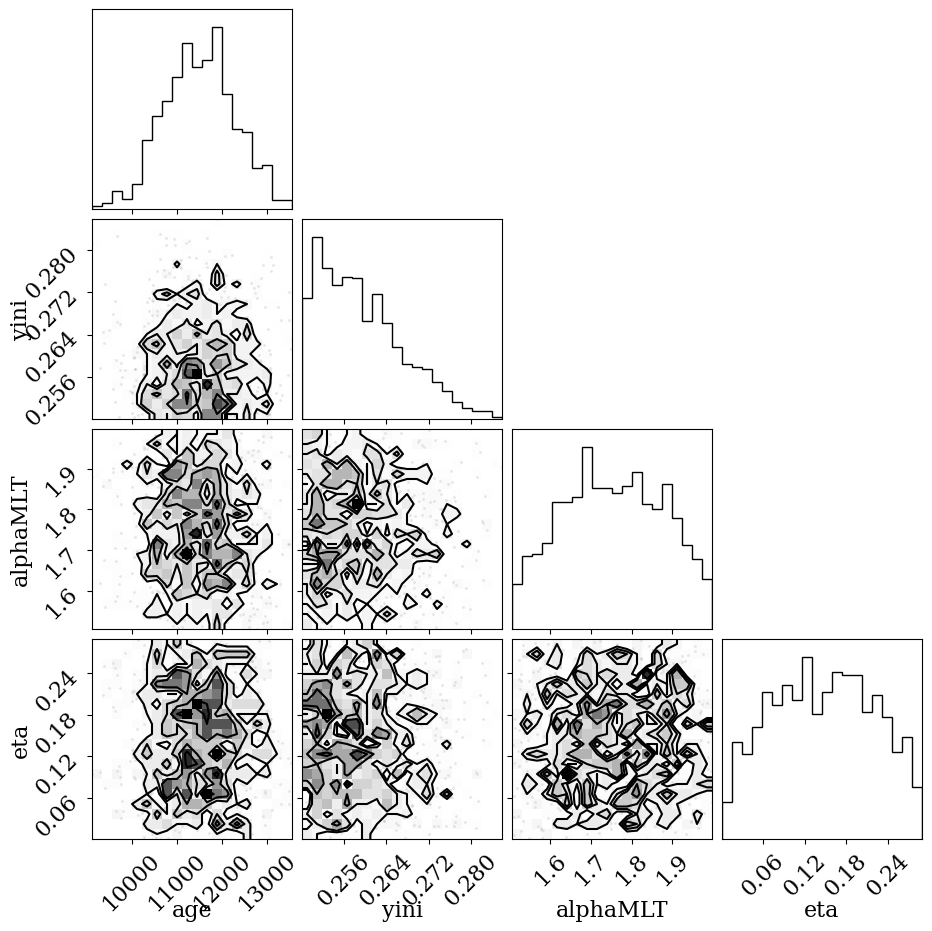

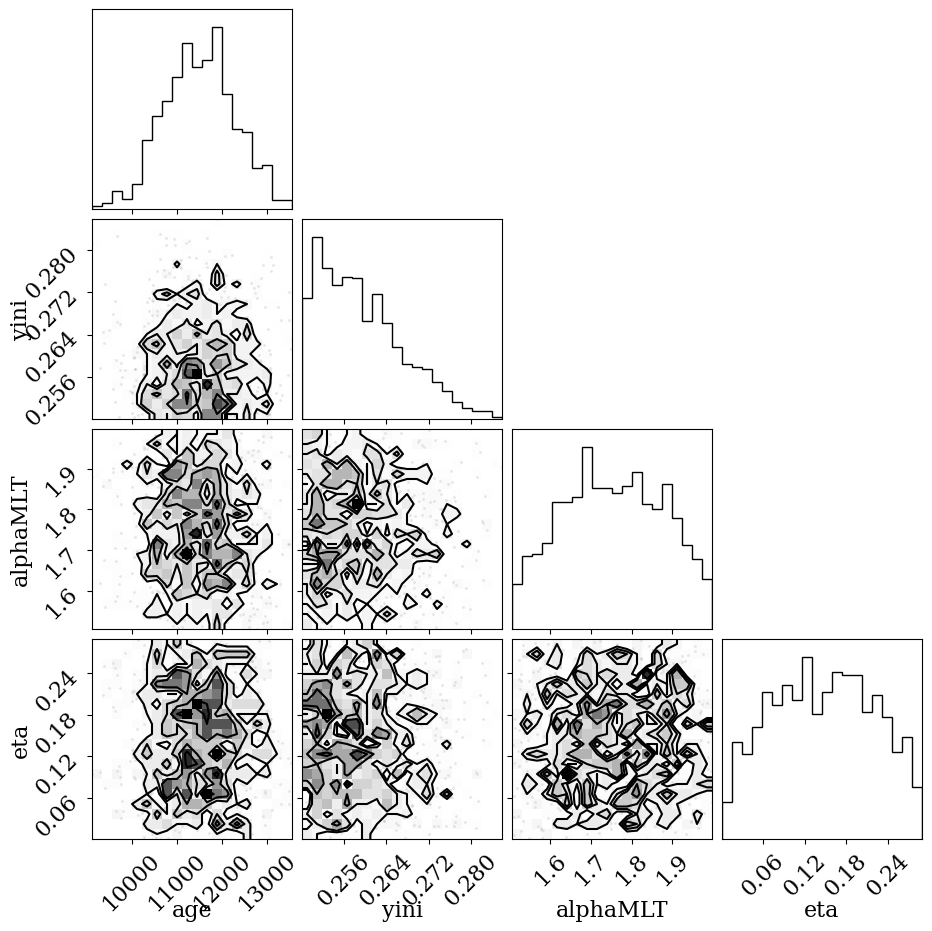

In [161]:
corner.corner(dd['C'], group="prior", var_names = ['age', 'yini', 'alphaMLT', 'eta'], )

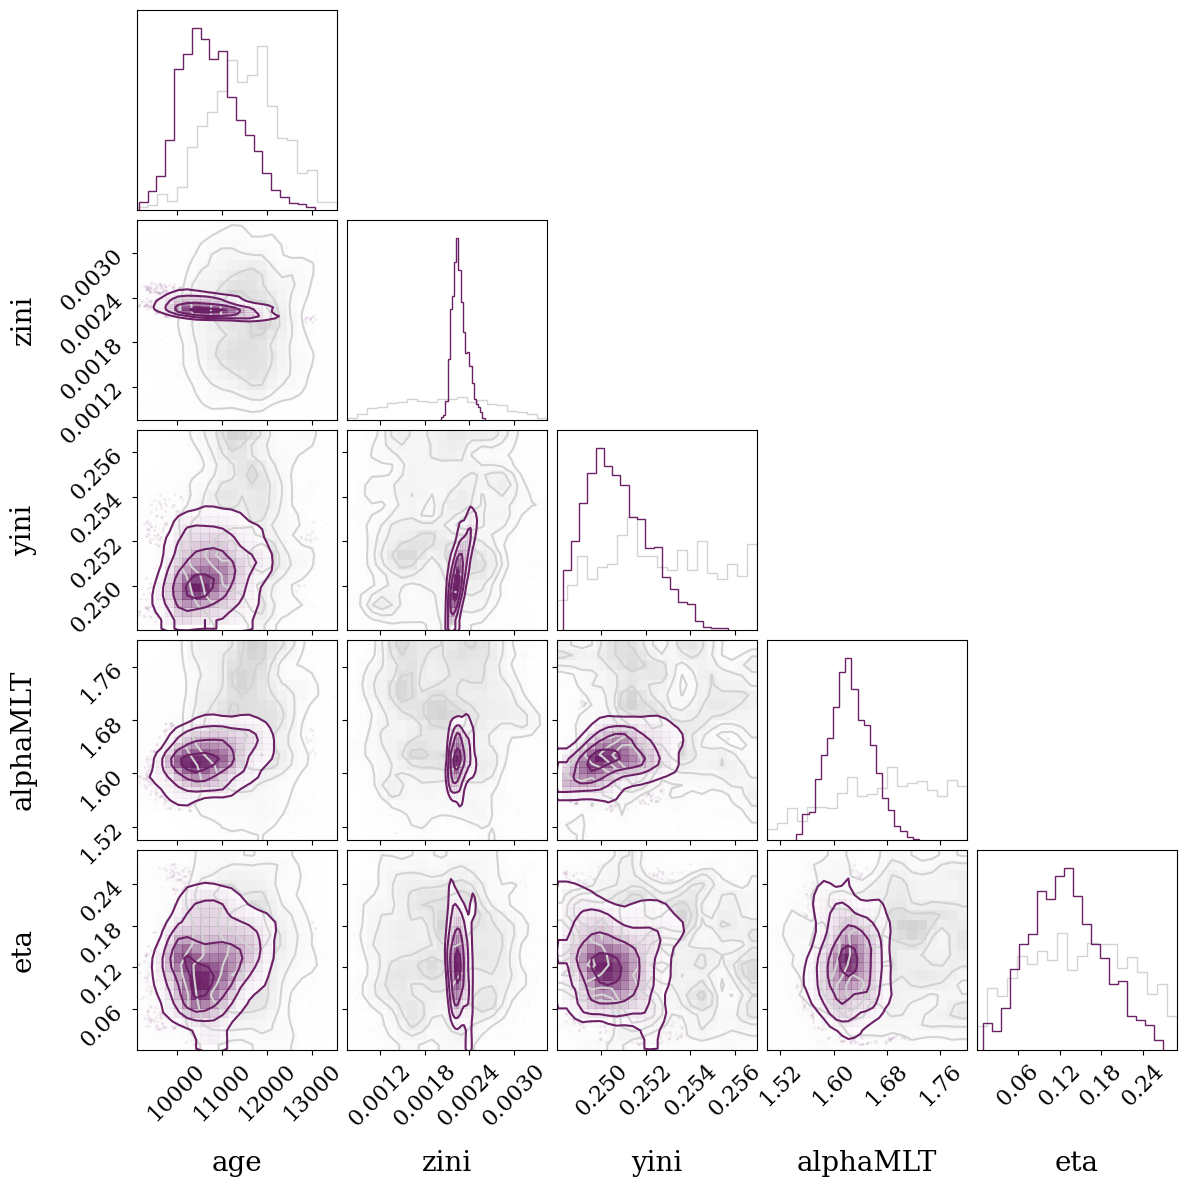

In [175]:

fig = corner.corner(dd['C'], group="prior", var_names = ['age', 'zini', 'yini', 'alphaMLT', 'eta'], smooth = True,  hist_kwargs={'density':True}, color = 'lightgray',  label_kwargs={ 'fontsize':20}, tick_kwargs={'fontsize':16}, labelpad = 0.2, range = [1, 1, (0.248, 0.257), (1.5, 1.8), 1])

corner.corner(dd['C'], group="posterior", var_names = ['age', 'zini', 'yini', 'alphaMLT', 'eta'],  smooth = True, fig = fig, hist_kwargs={'density':True}, color = colors[2], label_kwargs={ 'fontsize':20}, tick_kwargs={'fontsize':16}, labelpad = 0.2)
plt.show()

In [204]:
for i in params:
    med = dd['B'].posterior[i].quantile(0.5).data
    ulim = dd['B'].posterior[i].quantile(0.84).data
    llim = dd['B'].posterior[i].quantile(0.16).data
    eup = ulim - med
    elow = med - llim
    print(fr'{i}:{med} +/- {eup}/{elow}')

age:12288.288454994228 +/- 578.939133307731/592.3643267888274
zini:0.0022519040691345886 +/- 9.343110777755006e-05/8.71696000028033e-05
alphaMLT:1.5730740546070145 +/- 0.024323818327340874/0.023379950087701884
yini:0.2515166573683181 +/- 0.0013286249320311194/0.0013780595324349165
alphaFe:0.3993892395056434 +/- 0.020733596620242822/0.01511139108243198
eta:0.12950090458620234 +/- 0.03867073062457696/0.039116468164289805
fnumax:1.0955524898499105 +/- 0.01183435419496548/0.012993930350621907
fdnu:1.0273109534742355 +/- 0.009187976570621537/0.007830243549401539
dT:123.06635170795852 +/- 10.50116053599072/12.66804793209512


In [188]:
dd['C'].posterior['age'].quantile(0.16).data 

array(10691.84777606)

In [196]:
med.round(2)

np.float64(94.92)